# Key Insights

## 1. Large Transaction Dataset with Rich Behavioral Information
The dataset contains 95,662 transaction records and 16 features describing customer activity, transaction characteristics, channels, products, and fraud outcomes. This provides a strong foundation for customer behavior analysis and credit risk modeling.

## 2. Fraud Cases Are Extremely Rare
Only 193 transactions (approximately 0.2%) are labeled as fraudulent, while 95,469 transactions are non-fraudulent. This indicates a highly imbalanced target distribution and highlights the importance of using appropriate evaluation metrics when building predictive models.

## 3. Transaction Amounts Exhibit Significant Skewness and Outliers
Exploratory analysis of Amount and Value revealed highly skewed distributions with several extreme values. This suggests that scaling or transformation techniques may be necessary during feature engineering and model training.

## 4. Customer Activity Is Concentrated in Specific Product Categories and Channels
The distribution of ProductCategory and ChannelId shows that customer activity is not evenly distributed across categories and transaction channels. These variables are likely to contain useful behavioral signals for customer segmentation and risk assessment.

## 5. Transaction Timing May Provide Predictive Signals
Analysis of TransactionStartTime indicates variation in transaction activity across different hours and dates. Temporal features such as transaction hour, day, and month may capture behavioral patterns that contribute to credit risk prediction.

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_processing import load_data, extract_datetime_features

In [9]:
df = load_data("../data/raw/data.csv")

In [10]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


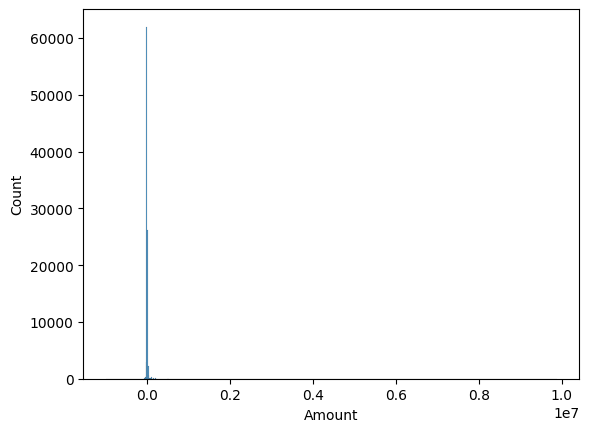

In [11]:
sns.histplot(df["Amount"])
plt.show()

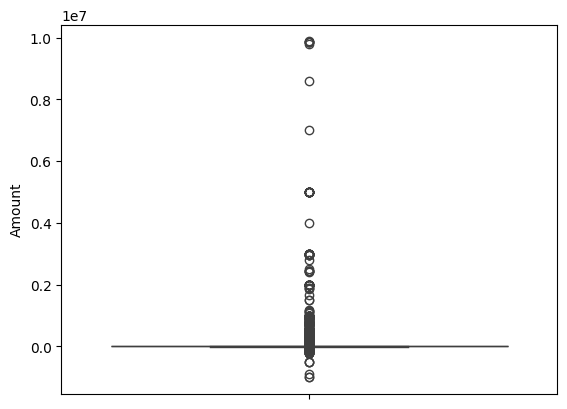

In [12]:
sns.boxplot(df["Amount"])
plt.show()

In [19]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.data_processing import load_data, create_customer_dataset
from src.target_engineering import create_rfm_target

df = load_data("../data/raw/data.csv")

# Step 1: customer dataset
customer_df = create_customer_dataset(df)

# Step 2: target
rfm = create_rfm_target(df)

# Step 3: merge
final_df = customer_df.merge(rfm, on="CustomerId")

print(final_df.head())
print(final_df["is_high_risk"].value_counts())

        CustomerId  total_transaction_amount  avg_transaction_amount  \
0     CustomerId_1                  -10000.0           -10000.000000   
1    CustomerId_10                  -10000.0           -10000.000000   
2  CustomerId_1001                   20000.0             4000.000000   
3  CustomerId_1002                    4225.0              384.090909   
4  CustomerId_1003                   20000.0             3333.333333   

   transaction_count  std_transaction_amount  is_high_risk  
0                  1                0.000000             1  
1                  1                0.000000             1  
2                  5             6558.963333             1  
3                 11              560.498966             0  
4                  6             6030.478146             0  
is_high_risk
0    2316
1    1426
Name: count, dtype: int64
